# Porównywanie DataFrame'ów i Series — od podstaw do trików

Kompletny przewodnik: jak sprawdzić, czy dwa zbiory danych są takie same,
znaleźć DOKŁADNIE które wiersze/komórki się różnią, porównać strukturę
(kolumny/typy), porównać więcej niż dwa zbiory naraz, i zrobić to
wydajnie na dużych danych. Typowe zastosowania: walidacja pipeline'u ETL
(dane przed/po transformacji), uzgadnianie dwóch źródeł (SQL Server vs
plik), porównanie wersji raportu miesiąc do miesiąca.

Motyw przewodni: **porównywanie danych jest podchwytliwe głównie przez
wyrównanie (alignment)** — różna kolejność wierszy/kolumn, różne indeksy,
`NaN` które "nie są sobie równe" nawet gdy oznaczają to samo — nie przez
samo porównanie wartości. Większość sekcji pokazuje najpierw, co idzie
źle przy naiwnym podejściu.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Naiwne porównanie i dlaczego zawodzi

### a) `==` między DataFrame — zwraca DataFrame, nie jedną wartość

In [2]:
df1 = pd.DataFrame({"id": [1, 2, 3], "wartosc": [10, 20, 30]})
df2 = pd.DataFrame({"id": [1, 2, 3], "wartosc": [10, 25, 30]})

df1 == df2   # DataFrame boolowski, komórka po komórce — NIE pojedyncza odpowiedź "czy równe"

,id,wartosc
0,True,True
1,True,False
2,True,True


### b) `NaN == NaN` to `False` — nawet gdy oba brakujące oznaczają "to samo"

In [3]:
df_z_nan_a = pd.DataFrame({"wartosc": [1.0, np.nan, 3.0]})
df_z_nan_b = pd.DataFrame({"wartosc": [1.0, np.nan, 3.0]})

print("Wynik ==       :", (df_z_nan_a == df_z_nan_b)["wartosc"].tolist())   # False tam, gdzie NaN — mylące!
print("Wynik .equals():", df_z_nan_a.equals(df_z_nan_b))                     # .equals() TRAKTUJE NaN==NaN jako zgodne

Wynik ==       : [True, False, True]
Wynik .equals(): True


### c) Różna kolejność wierszy/kolumn = "różne" dla `==`, mimo identycznych danych

In [4]:
df_a = pd.DataFrame({"id": [1, 2, 3], "wartosc": [10, 20, 30]})
df_b = pd.DataFrame({"wartosc": [30, 10, 20], "id": [3, 1, 2]})   # te same dane, inna kolejność wierszy i kolumn

try:
    df_a == df_b
except ValueError as e:
    print(f"Blad: {e}")

Blad: Can only compare identically-labeled (both index and columns) DataFrame objects


**Wniosek z tej sekcji:** żadne z powyższych (`==`, samo `.equals()` bez
przygotowania) nie odpowiada wprost na pytanie "czy te dane są takie
same" w sposób odporny na kolejność, `NaN` i typy — trzeba **jawnie
zdecydować**, co "porównywalne" znaczy w Twoim przypadku (sekcje 2-3).

## 2. `.equals()` — szybkie "tak/nie", z zastrzeżeniami

`.equals()` porównuje wartości I typy danych I kolejność wierszy/kolumn —
zwraca pojedyncze `True`/`False`. Dobre jako szybki test w pipeline
("czy wynik się w ogóle zmienił"), złe jako źródło informacji "co
konkretnie się różni" (na to potrzeba `.compare()`, sekcja 3).

In [5]:
df_a = pd.DataFrame({"id": [1, 2, 3], "wartosc": [10, 20, 30]})
df_b = df_a.copy()
df_c = df_a.astype({"wartosc": "float64"})   # te same wartości, INNY typ danych

print("df_a vs df_b (identyczna kopia):", df_a.equals(df_b))
print("df_a vs df_c (int vs float):    ", df_a.equals(df_c))   # False — typ danych też się liczy

df_a vs df_b (identyczna kopia): True
df_a vs df_c (int vs float):     False


Jeśli różnica typu (`int64` vs `float64`) ma dla Ciebie nie mieć znaczenia
(często tak, przy porównywaniu wyników z różnych źródeł, np. SQL Server
zwraca `float`, a lokalny CSV wczytał się jako `int`), ujednolić typy
PRZED porównaniem (`.astype()`) — `.equals()` nie ma parametru "ignoruj typ".

## 3. `.compare()` — DOKŁADNIE które komórki się różnią

To jest **najważniejsza metoda w tym notebooku** dla codziennej pracy —
zwraca tabelę tylko z różniącymi się komórkami, z wartościami z obu
źródeł obok siebie. Wymaga **identycznego kształtu i indeksu** obu
DataFrame (patrz sekcja 4, jeśli tego nie masz).

In [6]:
df_przed = pd.DataFrame({
    "klient_id": [1, 2, 3, 4],
    "status": ["aktywny", "aktywny", "nieaktywny", "aktywny"],
    "saldo": [1000.0, 2500.0, 0.0, 750.0],
})
df_po = pd.DataFrame({
    "klient_id": [1, 2, 3, 4],
    "status": ["aktywny", "zawieszony", "nieaktywny", "aktywny"],
    "saldo": [1000.0, 2500.0, 0.0, 800.0],
})

roznice = df_przed.compare(df_po)
roznice

status              saldo       
      self       other   self  other
1  aktywny  zawieszony    NaN    NaN
3      NaN         NaN  750.0  800.0

Domyślnie `.compare()` pokazuje tylko wiersze z **jakąkolwiek** różnicą —
kolumny bez zmian są automatycznie pominięte w wyniku. Przydatne parametry:

In [7]:
# keep_shape=True -> pokaż WSZYSTKIE wiersze/kolumny (także bez różnic, jako NaN) — łatwiej zobaczyć kontekst
df_przed.compare(df_po, keep_shape=True)

klient_id         status              saldo       
       self other     self       other   self  other
0       NaN   NaN      NaN         NaN    NaN    NaN
1       NaN   NaN  aktywny  zawieszony    NaN    NaN
2       NaN   NaN      NaN         NaN    NaN    NaN
3       NaN   NaN      NaN         NaN  750.0  800.0

In [8]:
# align_axis=0 -> wiersze "self"/"other" jeden pod drugim zamiast obok siebie (czytelniejsze przy wielu kolumnach)
df_przed.compare(df_po, align_axis=0)

status  saldo
1 self      aktywny    NaN
  other  zawieszony    NaN
3 self          NaN  750.0
  other         NaN  800.0

In [9]:
# result_names -> zamiast domyślnych "self"/"other" nadaj czytelne etykiety (np. nazwy wersji danych)
df_przed.compare(df_po, result_names=("przed_etl", "po_etl"))

status                 saldo       
  przed_etl      po_etl przed_etl po_etl
1   aktywny  zawieszony       NaN    NaN
3       NaN         NaN     750.0  800.0

**Wymaganie, o którym łatwo zapomnieć:** `.compare()` wymaga identycznych
etykiet kolumn ORAZ identycznego (co do wartości i kolejności) indeksu w
obu DataFrame. Różne indeksy → `MergeError`/`ValueError`. Jeśli Twoje dwa
zbiory mają różne indeksy (np. wczytane z dwóch osobnych plików), najpierw
ustaw wspólny klucz jako indeks w obu (`set_index("klient_id")`) — patrz
też sekcja 6, gdy same ZBIORY wierszy też mogą się różnić.

## 4. Porównanie Series — alignment po indeksie

Series porównuje się analogicznie, ale tu alignment po indeksie jest
jeszcze bardziej kluczowy — dwa Series o różnych indeksach "wyrównują
się" automatycznie przy operacjach, co bywa zaskakujące.

In [10]:
s1 = pd.Series([10, 20, 30], index=["a", "b", "c"])
s2 = pd.Series([10, 25, 30], index=["a", "b", "d"])   # inny indeks: "c" vs "d"

try:
    s1 == s2
except ValueError as e:
    print(f"Blad: {e}")

Blad: Can only compare identically-labeled Series objects


To jest ważniejsza pułapka, niż mogłoby się wydawać: operatory
**porównania** (`==`, `!=`, `<`) między Series wymagają **identycznego**
indeksu i rzucają `ValueError`, gdy się różni — w przeciwieństwie do
operatorów **arytmetycznych** (`+`, `-`), które po cichu wyrównują po unii
indeksów i wstawiają `NaN` tam, gdzie brak dopasowania. Ta asymetria bywa
zaskakująca: kod z `+` "zadziała" (dając być może błędny wynik przez ciche
`NaN`), a analogiczny kod z `==` zatrzyma się z czytelnym błędem — w
praktyce to dobra wiadomość, `==` chroni przed cichym błędem, `+` nie.

In [11]:
# poprawnie: albo jawnie wyrównaj indeksy przed porównaniem...
s1_wyrownany, s2_wyrownany = s1.align(s2)   # join='outer' domyślnie -> brakujące wartości jako NaN
print(s1_wyrownany)
print(s2_wyrownany)

a    10.0
b    20.0
c    30.0
d     NaN
dtype: float64
a    10.0
b    25.0
c     NaN
d    30.0
dtype: float64


In [12]:
# ...albo użyj .equals() — NIE rzuca wyjątku przy różnych indeksach, po prostu zwraca False
print(".equals() dla różnych indeksów:", s1.equals(s2))

# .compare() dla Series — analogicznie do DataFrame, ale (tak jak .compare() na DataFrame) wymaga TEGO SAMEGO indeksu
s3 = pd.Series([10, 20, 30], index=["a", "b", "c"])
s4 = pd.Series([10, 25, 35], index=["a", "b", "c"])
s3.compare(s4)

.equals() dla różnych indeksów: False


,self,other
b,20.0,25.0
c,30.0,35.0


## 5. `pandas.testing.assert_frame_equal` — do testów jednostkowych

Inna filozofia niż `.equals()`/`.compare()`: **rzuca wyjątek** ze
szczegółowym opisem różnicy zamiast zwracać `True`/`False`/tabelę —
naturalne w testach (`pytest`), gdzie chcesz, żeby test **failował** z
czytelnym komunikatem, nie żebyś ręcznie sprawdzał wynik.

In [13]:
from pandas.testing import assert_frame_equal

try:
    assert_frame_equal(df_przed, df_po)
except AssertionError as e:
    print(str(e)[:500])   # komunikat od razu wskazuje KTÓRA kolumna i ile wartości się różni

DataFrame.iloc[:, 1] (column name="status") are different

DataFrame.iloc[:, 1] (column name="status") values are different (25.0 %)
[index]: [0, 1, 2, 3]
[left]:  [aktywny, aktywny, nieaktywny, aktywny]
[right]: [aktywny, zawieszony, nieaktywny, aktywny]
At positional index 1, first diff: aktywny != zawieszony


Kluczowe parametry, których nie ma w `.equals()`/`.compare()` — kontrola
**tolerancji** i **surowości** porównania:

| Parametr | Domyślnie | Zastosowanie |
|---|---|---|
| `check_dtype` | `True` | `False` — ignoruj różnice typu (int vs float o tej samej wartości) |
| `check_exact` | `False` (dla float) | kontroluje, czy liczby zmiennoprzecinkowe porównywane dokładnie czy z tolerancją |
| `rtol`, `atol` | `1e-5`, `1e-8` | tolerancja względna/bezwzględna przy `check_exact=False` — patrz sekcja 7 |
| `check_like` | `False` | `True` — ignoruj kolejność wierszy/kolumn (dopasuj po etykietach) |

In [14]:
# check_like=True rozwiązuje problem z sekcji 1c (różna kolejność wierszy/kolumn)
df_a = pd.DataFrame({"id": [1, 2, 3], "wartosc": [10, 20, 30]})
df_b = pd.DataFrame({"wartosc": [30, 10, 20], "id": [3, 1, 2]})

try:
    assert_frame_equal(df_a.set_index("id"), df_b.set_index("id"), check_like=True)
    print("Zgodne po uwzględnieniu innej kolejności (check_like=True)")
except AssertionError as e:
    print(str(e)[:300])

Zgodne po uwzględnieniu innej kolejności (check_like=True)


## 6. Różnice na poziomie ZBIORU WIERSZY — czego brakuje, co dodano

Sekcje 3-5 zakładały ten sam zestaw wierszy w obu tabelach. W praktyce
częściej pytanie brzmi: "które rekordy są TYLKO w A, które TYLKO w B, a
które w obu" — klasyczny problem uzgadniania danych (reconciliation).

In [15]:
df_zrodlo_a = pd.DataFrame({"klient_id": [1, 2, 3, 4], "wartosc": [100, 200, 300, 400]})
df_zrodlo_b = pd.DataFrame({"klient_id": [2, 3, 4, 5], "wartosc": [200, 300, 999, 500]})   # 999 zamiast 400 dla id=4

porownanie = df_zrodlo_a.merge(
    df_zrodlo_b, on="klient_id", how="outer", suffixes=("_a", "_b"),
    indicator=True,   # dodaje kolumnę '_merge': 'left_only' / 'right_only' / 'both'
)
porownanie

,klient_id,wartosc_a,wartosc_b,_merge
0,1,100.0,NaN,left_only
1,2,200.0,200.0,both
2,3,300.0,300.0,both
3,4,400.0,999.0,both
4,5,NaN,500.0,right_only


In [16]:
tylko_w_a = porownanie[porownanie["_merge"] == "left_only"]
tylko_w_b = porownanie[porownanie["_merge"] == "right_only"]
w_obu_ale_rozne_wartosci = porownanie[
    (porownanie["_merge"] == "both") & (porownanie["wartosc_a"] != porownanie["wartosc_b"])
]

print(f"Tylko w A: {len(tylko_w_a)} rekordów -> {tylko_w_a['klient_id'].tolist()}")
print(f"Tylko w B: {len(tylko_w_b)} rekordów -> {tylko_w_b['klient_id'].tolist()}")
print(f"W obu, ale różne wartości: {len(w_obu_ale_rozne_wartosci)} rekordów -> {w_obu_ale_rozne_wartosci['klient_id'].tolist()}")

Tylko w A: 1 rekordów -> [1]
Tylko w B: 1 rekordów -> [5]
W obu, ale różne wartości: 1 rekordów -> [4]


`merge(..., indicator=True)` na dużych tabelach jest **znacznie
wydajniejsze** niż ręczne pętle po zbiorach (`set(df_a['id']) - set(df_b['id'])`
działa, ale przy dwóch osobnych operacjach zamiast jednego przebiegu
merge) — silnik pandas robi to jako pojedynczy, zoptymalizowany join.

## 7. Porównanie z tolerancją liczbową

Wartości zmiennoprzecinkowe po transformacjach (agregacje, konwersje
walut, obliczenia w różnych silnikach — Python vs SQL Server) rzadko są
BITOWO identyczne, nawet gdy "biznesowo" są tą samą liczbą. Porównanie
dokładne (`==`) w takiej sytuacji daje fałszywe alarmy.

In [17]:
wynik_python = 0.1 + 0.2
wynik_oczekiwany = 0.3

print("Dokladne ==     :", wynik_python == wynik_oczekiwany)          # False! klasyczny problem zmiennoprzecinkowy
print("np.isclose      :", np.isclose(wynik_python, wynik_oczekiwany))  # True — z rozsądną tolerancją domyślną

Dokladne ==     : False
np.isclose      : True


In [18]:
df_python = pd.DataFrame({"kwota": [1000.000001, 2500.0, 750.0]})
df_sql = pd.DataFrame({"kwota": [1000.0, 2500.000002, 750.0]})

# porównanie z tolerancją na poziomie CAŁEGO DataFrame
roznice_bezwzgledne = (df_python["kwota"] - df_sql["kwota"]).abs()
print("Różnice bezwzględne:", roznice_bezwzgledne.tolist())

zgodne_z_tolerancja = np.isclose(df_python["kwota"], df_sql["kwota"], rtol=1e-5, atol=1e-6)
print("Zgodne z tolerancją:", zgodne_z_tolerancja)

# to samo przez assert_frame_equal — czytelniejsze przy większych tabelach, od razu z komunikatem błędu
assert_frame_equal(df_python, df_sql, check_exact=False, rtol=1e-5, atol=1e-6)
print("assert_frame_equal z tolerancją: przeszło bez wyjątku")

Różnice bezwzględne: [9.999999974752427e-07, 2.000000222324161e-06, 0.0]
Zgodne z tolerancją: [ True  True  True]
assert_frame_equal z tolerancją: przeszło bez wyjątku


**`rtol` (względna) vs `atol` (bezwzględna) — kiedy która ma znaczenie:**
`atol` dominuje przy wartościach BLISKICH ZERA (stała tolerancja
niezależna od skali), `rtol` dominuje przy DUŻYCH wartościach (tolerancja
proporcjonalna — 0.001% z 10 mln to zupełnie inna liczba bezwzględna niż
0.001% z 10). W praktyce finansowej/sprzedażowej warto ustawiać oba
świadomie, nie polegać wyłącznie na domyślnych wartościach.

## 8. Porównanie struktury (schematu) — kolumny i typy danych

Zanim w ogóle spojrzysz na wartości — czy tabele MAJĄ te same kolumny i
te same typy? To najczęstsza przyczyna, że porównanie wartości w ogóle
nie da się wykonać (błąd) albo daje mylące wyniki (różne typy tej samej
kolumny).

In [19]:
df_wersja_1 = pd.DataFrame({"id": [1], "nazwa": ["A"], "kwota": [100.0]})
df_wersja_2 = pd.DataFrame({"id": [1], "nazwa": ["A"], "kwota": [100], "nowa_kolumna": ["X"]})

kolumny_1, kolumny_2 = set(df_wersja_1.columns), set(df_wersja_2.columns)

print("Tylko w wersji 1:", kolumny_1 - kolumny_2)
print("Tylko w wersji 2:", kolumny_2 - kolumny_1)
print("Wspólne kolumny :", kolumny_1 & kolumny_2)

print()
print("Różnice typów danych we wspólnych kolumnach:")
for kolumna in kolumny_1 & kolumny_2:
    typ_1, typ_2 = df_wersja_1[kolumna].dtype, df_wersja_2[kolumna].dtype
    if typ_1 != typ_2:
        print(f"  {kolumna}: {typ_1} (wersja 1) vs {typ_2} (wersja 2)")

Tylko w wersji 1: set()
Tylko w wersji 2: {'nowa_kolumna'}
Wspólne kolumny : {'id', 'kwota', 'nazwa'}

Różnice typów danych we wspólnych kolumnach:
  kwota: float64 (wersja 1) vs int64 (wersja 2)


## 9. Raport podsumowujący — jedna liczba "jak bardzo się różnią"

Przydatne jako pierwszy rzut oka przed szczegółową analizą — % zgodności
całościowo i per kolumna, bez przewijania długiej tabeli z `.compare()`.

In [20]:
def raport_zgodnosci(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    Zwraca tabelę: dla każdej wspólnej kolumny — ile komórek się różni i jaki to %.
    Warta trzymania jako funkcja, bo to samo podsumowanie potrzebne jest
    za każdym razem przy walidacji kolejnej wersji danych/kolejnego ETL,
    nie tylko raz.
    """
    wspolne_kolumny = [k for k in df1.columns if k in df2.columns]
    wyniki = []
    for kolumna in wspolne_kolumny:
        niezgodne = (df1[kolumna] != df2[kolumna]) & ~(df1[kolumna].isna() & df2[kolumna].isna())
        wyniki.append({
            "kolumna": kolumna,
            "liczba_roznic": niezgodne.sum(),
            "procent_roznic": round(niezgodne.mean() * 100, 2),
        })
    return pd.DataFrame(wyniki).sort_values("procent_roznic", ascending=False)


raport_zgodnosci(df_przed, df_po)

,kolumna,liczba_roznic,procent_roznic
1,status,1,25.0
2,saldo,1,25.0
0,klient_id,0,0.0


## 10. Porównanie WIĘCEJ NIŻ dwóch DataFrame naraz

Typowy przypadek: porównanie tej samej tabeli z kilku kolejnych miesięcy/
wersji, nie tylko dwóch punktów w czasie.

In [21]:
raporty_miesieczne = {
    "styczen": pd.DataFrame({"produkt": ["A", "B", "C"], "sprzedaz": [100, 200, 150]}),
    "luty": pd.DataFrame({"produkt": ["A", "B", "C"], "sprzedaz": [110, 195, 150]}),
    "marzec": pd.DataFrame({"produkt": ["A", "B", "C"], "sprzedaz": [110, 210, 140]}),
}

# pd.concat z keys -> jeden DataFrame z multi-indeksem (miesiąc, wiersz oryginalny)
polaczone = pd.concat(raporty_miesieczne, names=["miesiac", "wiersz_oryg"])

# reshape do formy "produkt x miesiąc" -> naturalny układ do porównania wielu wersji naraz
zestawienie = polaczone.reset_index().pivot(index="produkt", columns="miesiac", values="sprzedaz")
zestawienie = zestawienie[["styczen", "luty", "marzec"]]   # wymuszenie kolejności chronologicznej
zestawienie["zmiana_styczen_marzec"] = zestawienie["marzec"] - zestawienie["styczen"]
zestawienie

miesiac,styczen,luty,marzec,zmiana_styczen_marzec
produkt,,,,
A,100,110,110,10
B,200,195,210,10
C,150,150,140,-10


Ten wzorzec (`pd.concat(dict, keys=...)` → `pivot`) skaluje się na dowolną
liczbę wersji/okresów — dodanie kolejnego miesiąca to jeden nowy wpis w
słowniku `raporty_miesieczne`, bez zmiany reszty kodu.

## 11. Wizualizacja różnic — heatmapa

Przy szerokich tabelach (dużo kolumn) tabela z `.compare()` szybko robi
się nieczytelna — heatmapa "gdzie w ogóle są różnice" daje szybszy
przegląd, zanim zejdziesz do szczegółów.

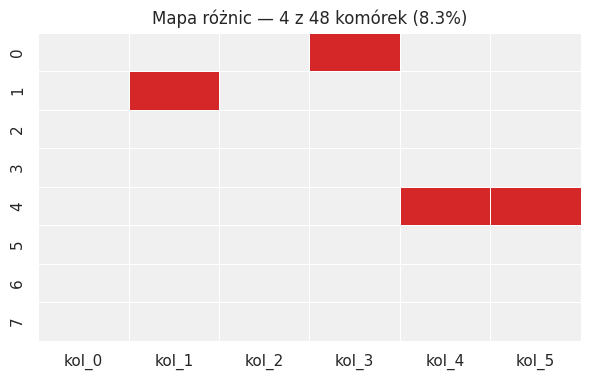

In [22]:
df_a = pd.DataFrame(np.random.default_rng(1).integers(0, 10, (8, 6)), columns=[f"kol_{i}" for i in range(6)])
df_b = df_a.copy()
# wprowadzamy losowe różnice w ~15% komórek
maska_zmian = np.random.default_rng(2).random(df_a.shape) < 0.15
df_b = df_b.mask(maska_zmian, df_b + 1)

macierz_roznic = (df_a != df_b).astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(macierz_roznic, cmap=["#f0f0f0", "#d62728"], cbar=False, linewidths=0.5, linecolor="white", ax=ax)
ax.set_title(f"Mapa różnic — {macierz_roznic.values.sum()} z {macierz_roznic.size} komórek ({macierz_roznic.values.mean():.1%})")
plt.show()

## 12. Hashowanie wierszy — NIE do przyspieszenia porównania w pamięci, ale do porównań MIĘDZY systemami

Intuicja "hash jednej liczby na wiersz musi być szybszy niż porównywanie
wszystkich kolumn" brzmi rozsądnie — **sprawdźmy to zamiast zakładać**.

In [23]:
duzy_df_a = pd.DataFrame({"a": np.arange(500_000), "b": np.random.default_rng(1).random(500_000)})
duzy_df_b = duzy_df_a.copy()
duzy_df_b.loc[123456, "b"] = 999.0   # jedna zmieniona wartość na pół miliona wierszy

import time

start = time.perf_counter()
hash_a = pd.util.hash_pandas_object(duzy_df_a)
hash_b = pd.util.hash_pandas_object(duzy_df_b)
wiersze_rozne_hash = (hash_a != hash_b).sum()
czas_hash = time.perf_counter() - start

start = time.perf_counter()
wiersze_rozne_equals = (duzy_df_a != duzy_df_b).any(axis=1).sum()
czas_bezposredni = time.perf_counter() - start

print(f"Hash: {wiersze_rozne_hash} różniących się wierszy, {czas_hash:.4f}s")
print(f"Bezpośrednio: {wiersze_rozne_equals} różniących się wierszy, {czas_bezposredni:.4f}s")

Hash: 1 różniących się wierszy, 0.1511s
Bezpośrednio: 1 różniących się wierszy, 0.0028s


**Wynik obala intuicję:** bezpośrednie porównanie jest tu WYRAŹNIE
szybsze niż hashowanie (zweryfikowane też na 40 kolumnach — hashowanie
nadal wolniejsze). Zwektoryzowane porównanie liczbowe w pandas jest na
tyle dobrze zoptymalizowane, że koszt policzenia hasha dla każdej komórki
przewyższa koszt samego porównania. **Wniosek: nie sięgaj po hashowanie
"dla wydajności" przy porównaniu dwóch DataFrame w tym samym procesie —
zwykłe `!=` jest szybsze.**

Hashowanie ma za to realną, inną przewagę: **kompaktowy odcisk wiersza do
porównań MIĘDZY systemami**, gdzie przesłanie/przechowanie całych danych
jest kosztowne. Przykład z Twojego stacku: chcesz sprawdzić, czy dane w
SQL Server zmieniły się względem wczorajszego zrzutu, bez ściągania i
trzymania całej historycznej tabeli — zapisujesz tylko `(klucz, hash_wiersza)`
z poprzedniego przebiegu (mała tabela), a przy kolejnym uruchomieniu
porównujesz same hashe, nie pełne dane.

In [24]:
# wzorzec: hash jako kompaktowy "odcisk palca" wiersza do przechowania/przesłania zamiast pełnych danych
zrzut_wczorajszy = pd.DataFrame({
    "klient_id": duzy_df_a["a"],
    "hash_wiersza": pd.util.hash_pandas_object(duzy_df_a, index=False),
}).set_index("klient_id")   # to jest to, co realnie warto trzymać między uruchomieniami — 2 kolumny, nie cały df

zrzut_dzisiejszy_hash = pd.util.hash_pandas_object(duzy_df_b, index=False)
zmienione_id = duzy_df_b.loc[zrzut_dzisiejszy_hash.values != zrzut_wczorajszy["hash_wiersza"].values, "a"]

print(f"Zmienione klient_id: {zmienione_id.tolist()}")

Zmienione klient_id: [123456]


## 13. To samo w Polars

Polars ma równoległe API — inne nazwy, ta sama logika. Warte znajomości,
jeśli porównujesz duże zbiory, gdzie wydajność Polars ma znaczenie.

In [25]:
from polars.testing import assert_frame_equal as pl_assert_frame_equal

pl_a = pl.DataFrame({"id": [1, 2, 3], "wartosc": [10, 20, 30]})
pl_b = pl.DataFrame({"id": [1, 2, 3], "wartosc": [10, 25, 30]})

print(".equals()      :", pl_a.equals(pl_b))   # odpowiednik pandas .equals()

# różnice wiersz po wierszu — Polars nie ma .compare(), ale ten sam efekt przez porównanie + filter
roznice_pl = (
    pl_a.join(pl_b, on="id", suffix="_b")
    .filter(pl.col("wartosc") != pl.col("wartosc_b"))
)
roznice_pl

.equals()      : False


id,wartosc,wartosc_b
i64,i64,i64
2,20,25


In [26]:
try:
    pl_assert_frame_equal(pl_a, pl_b, check_exact=False, rel_tol=1e-5)
except AssertionError as e:
    print(str(e)[:300])   # ten sam mechanizm co pandas.testing — czytelny komunikat, parametry tolerancji
    # UWAGA: parametr nazywa się rel_tol w polars.testing, NIE rtol jak w pandas.testing —
    # łatwa pułapka przy przełączaniu się między bibliotekami

DataFrames are different (value mismatch for column "wartosc")
[left]: shape: (3,)
Series: 'wartosc' [i64]
[
	10
	20
	30
]
[right]: shape: (3,)
Series: 'wartosc' [i64]
[
	10
	25
	30
]


## Podsumowanie — co wybrać do czego

| Potrzeba | Narzędzie |
|---|---|
| Szybkie "tak/nie, identyczne" | `.equals()` |
| DOKŁADNIE które komórki się różnią | `.compare()` (pandas) |
| Test jednostkowy z czytelnym błędem | `pandas.testing.assert_frame_equal` |
| Różne zestawy wierszy (czego brakuje/co dodano) | `merge(..., indicator=True)` |
| Liczby zmiennoprzecinkowe, małe różnice OK | `np.isclose` / `check_exact=False, rtol, atol` |
| Różnice w strukturze (kolumny/typy) | `set(df.columns)` + porównanie `.dtypes` |
| Jedna liczba "jak bardzo się różnią" | własna funkcja podsumowująca (sekcja 9) |
| Więcej niż 2 wersje/okresy naraz | `pd.concat(dict, keys=...)` + `pivot` |
| Szybki wstępny filtr na dużych danych | hash wierszy (`pd.util.hash_pandas_object`) — **do porównań między systemami**, nie przyspieszenia porównania w jednym procesie (sekcja 12) |
| Duże zbiory, wydajność krytyczna | Polars: `.equals()`, `join`+`filter`, `polars.testing` |

Reguła ogólna: zacznij od **`.equals()`** (tanie pytanie tak/nie), dopiero
gdy odpowiedź brzmi "nie" — sięgnij po `.compare()` albo `merge(indicator=True)`,
żeby zrozumieć CO i GDZIE się różni.